# Stochastic Differential Equations — General Theory & Existence/Uniqueness

## Cell 1: What is an SDE?

A **Stochastic Differential Equation (SDE)** extends ordinary differential equations by adding noise:

$$dX(t) = \underbrace{b(X(t))\,dt}_{\text{drift}} + \underbrace{\sigma(X(t))\,dW(t)}_{\text{diffusion}}$$

| Symbol | Meaning |
|--------|---------|
| $X(t)$ | Stochastic process (the unknown) |
| $b(x)$ | Drift coefficient |
| $\sigma(x)$ | Diffusion coefficient |
| $W(t)$ | Standard Brownian motion |

### Integral Form

$$X(t) = X(0) + \int_0^t b(X(s))\,ds + \int_0^t \sigma(X(s))\,dW(s)$$

The last integral is an **Itô stochastic integral**, defined as the $L^2$-limit of Riemann sums where the integrand is evaluated at the **left endpoint** of each subinterval.

### From ODE to SDE

The same drift with different noise levels produces dramatically different behavior. With small noise, paths cluster around the deterministic solution. With large noise, the deterministic trend is almost completely obscured by random fluctuations.



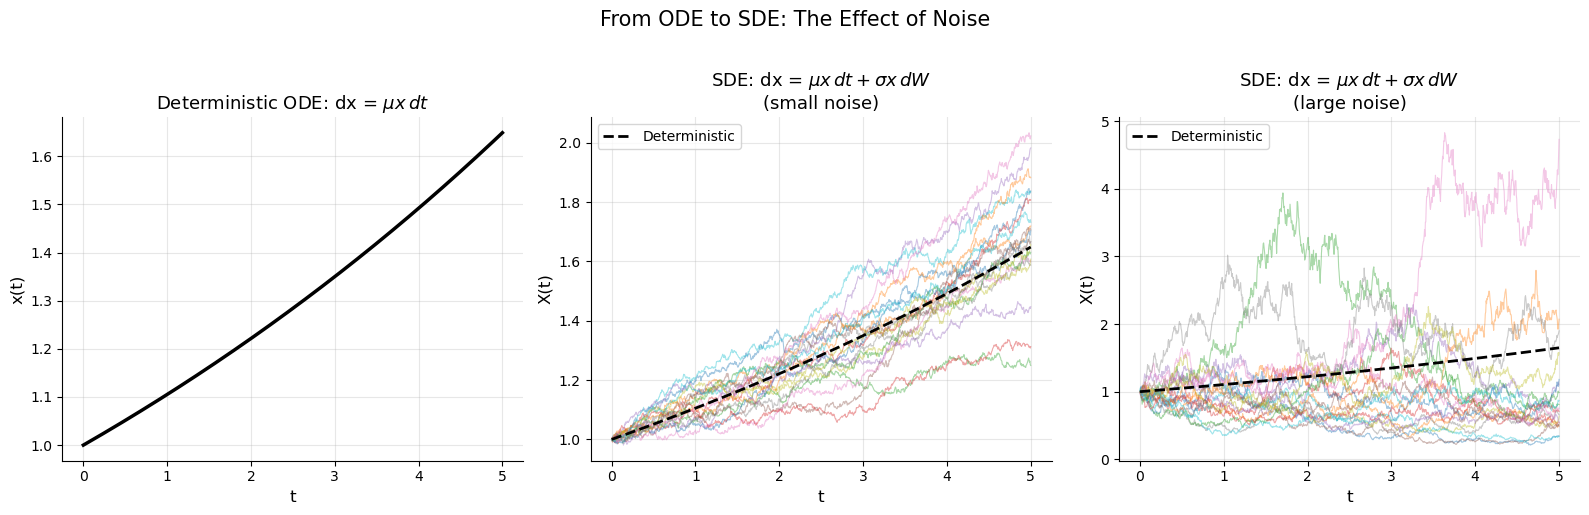

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def simulate_gbm(mu, sigma, x0, T, n_steps, n_paths):
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    X = np.zeros((n_paths, n_steps + 1))
    X[:, 0] = x0
    for i in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        X[:, i+1] = X[:, i] + mu * X[:, i] * dt + sigma * X[:, i] * dW
    return t, X

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Deterministic ODE
ax = axes[0]
mu, x0, T = 0.1, 1.0, 5.0
t = np.linspace(0, T, 500)
x_det = x0 * np.exp(mu * t)
ax.plot(t, x_det, 'k-', lw=2.5)
ax.set_title('Deterministic ODE: dx = ' + r'$\mu x \, dt$', fontsize=13)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('x(t)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Small noise
ax = axes[1]
t_stoch, X_stoch = simulate_gbm(mu=0.1, sigma=0.05, x0=1.0, T=5.0, n_steps=1000, n_paths=20)
for k in range(20):
    ax.plot(t_stoch, X_stoch[k], alpha=0.4, lw=0.8)
ax.plot(t, x_det, 'k--', lw=2, label='Deterministic')
ax.set_title('SDE: dx = ' + r'$\mu x \, dt + \sigma x \, dW$' + '\n(small noise)', fontsize=13)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Large noise
ax = axes[2]
t_stoch2, X_stoch2 = simulate_gbm(mu=0.1, sigma=0.4, x0=1.0, T=5.0, n_steps=1000, n_paths=20)
for k in range(20):
    ax.plot(t_stoch2, X_stoch2[k], alpha=0.4, lw=0.8)
ax.plot(t, x_det, 'k--', lw=2, label='Deterministic')
ax.set_title('SDE: dx = ' + r'$\mu x \, dt + \sigma x \, dW$' + '\n(large noise)', fontsize=13)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('From ODE to SDE: The Effect of Noise', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## Cell 2: Existence & Uniqueness Theorem

### The Classical Result (Itô, 1951)

Consider the SDE:

$$dX(t) = b(X(t))\,dt + \sigma(X(t))\,dW(t), \quad X(0) = x_0$$

**Theorem**: If $b$ and $\sigma$ satisfy:

1. **Global Lipschitz condition**:
   $$|b(x) - b(y)| + |\sigma(x) - \sigma(y)| \leq K|x - y| \quad \forall x,y$$

2. **Linear growth condition**:
   $$|b(x)|^2 + |\sigma(x)|^2 \leq C(1 + |x|^2) \quad \forall x$$

Then there exists a **unique strong solution** $X(t)$ for all $t \geq 0$.

### Why These Conditions?

| Condition | Purpose |
|-----------|---------|
| **Lipschitz** | Prevents "splitting" of solutions; ensures paths don't cross |
| **Linear growth** | Prevents explosion in finite time; keeps moments bounded |

The Lipschitz condition controls how fast coefficients can change. Without it, two nearby starting points can diverge arbitrarily, and the solution mapping becomes non-unique. The linear growth condition ensures that the drift and diffusion do not grow faster than linearly, which is necessary to prevent the solution from exploding to infinity in finite time.


## Cell 3: Lipschitz vs Non-Lipschitz

The left panel shows an Ornstein-Uhlenbeck-type SDE with Lipschitz drift $b(x) = -x$. All paths are well-behaved, mean-reverting, and unique. The right panel uses $b(x) = \sqrt{|x|}$, which violates Lipschitz at $x = 0$ because the derivative blows up. Starting exactly at zero, the non-Lipschitz drift allows multiple possible behaviors — the solution is not uniquely determined.


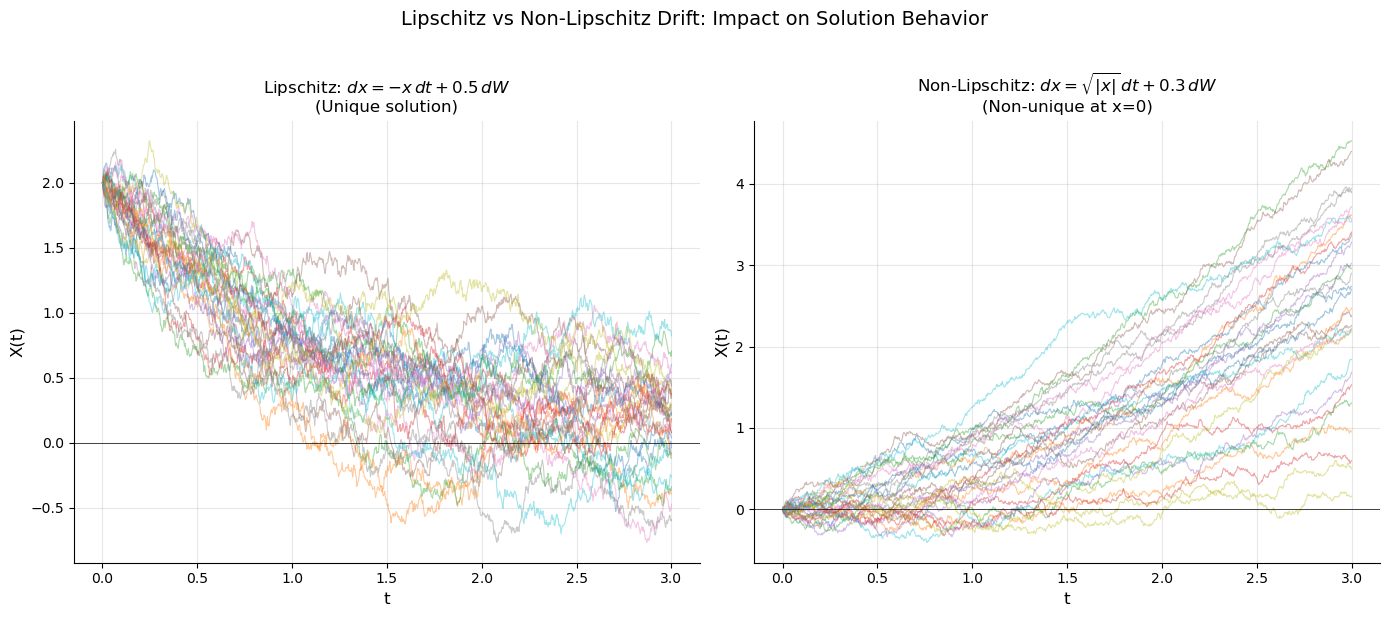

In [22]:
def simulate_euler(f, g, x0, T, n_steps, n_paths):
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    X = np.zeros((n_paths, n_steps + 1))
    X[:, 0] = x0
    for i in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        X[:, i+1] = X[:, i] + f(X[:, i]) * dt + g(X[:, i]) * dW
    return t, X

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lipschitz drift
ax = axes[0]
f_lip = lambda x: -x
g_lip = lambda x: 0.5 * np.ones_like(x)
t, X_lip = simulate_euler(f_lip, g_lip, x0=2.0, T=3.0, n_steps=1000, n_paths=30)
for k in range(30):
    ax.plot(t, X_lip[k], alpha=0.4, lw=0.8)
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_title(r'Lipschitz: $dx = -x \, dt + 0.5 \, dW$' + '\n(Unique solution)', fontsize=12)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Non-Lipschitz drift
ax = axes[1]
f_non = lambda x: np.sqrt(np.abs(x))
g_non = lambda x: 0.3 * np.ones_like(x)
t, X_non = simulate_euler(f_non, g_non, x0=0.0, T=3.0, n_steps=1000, n_paths=30)
for k in range(30):
    ax.plot(t, X_non[k], alpha=0.4, lw=0.8)
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_title(r'Non-Lipschitz: $dx = \sqrt{|x|} \, dt + 0.3 \, dW$' + '\n(Non-unique at x=0)', fontsize=12)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Lipschitz vs Non-Lipschitz Drift: Impact on Solution Behavior', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 4: Picard Iteration

Just as with ODEs, SDEs can be solved via **Picard iteration**:

$$X_{n+1}(t) = x_0 + \int_0^t b(X_n(s))\,ds + \int_0^t \sigma(X_n(s))\,dW(s)$$

Under Lipschitz conditions, this is a **contraction** in the appropriate metric space, guaranteeing convergence to the unique solution.

For the special case $dX = X\,dW$ with $X(0) = 1$, the exact solution is $X(t) = \exp(W(t) - t/2)$. The Picard iterates converge rapidly to this exact solution, with the $L^2$ error dropping by orders of magnitude after just a few iterations.


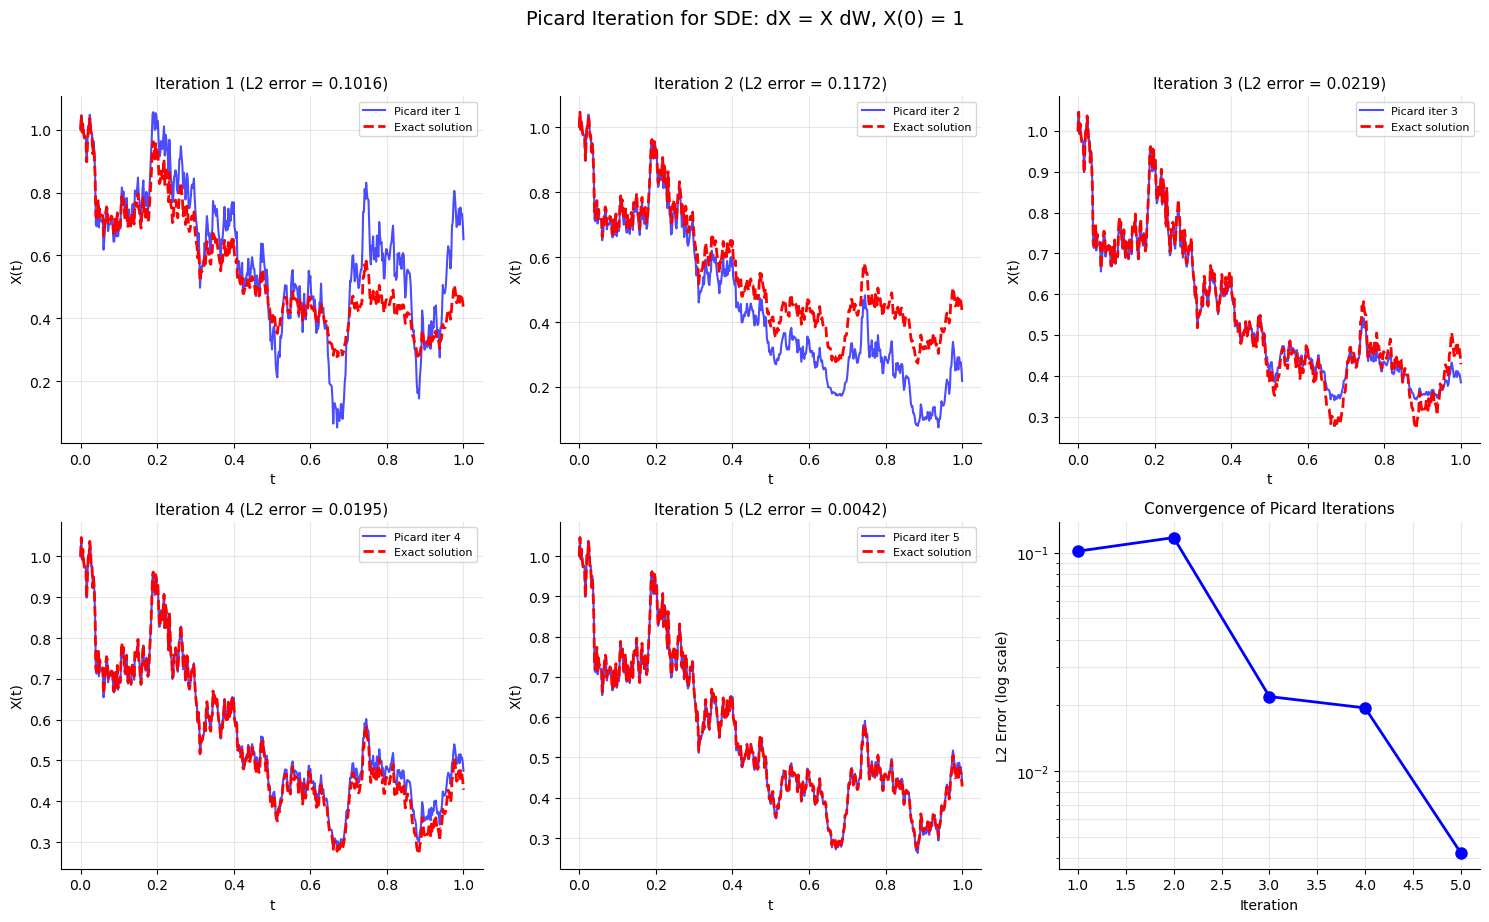

In [23]:
def picard_iteration_bm(x0, T, n_steps, n_paths, n_iter=5):
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    dW = np.random.normal(0, np.sqrt(dt), (n_paths, n_steps))
    W = np.zeros((n_paths, n_steps + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    
    # Exact solution for dX = X dW
    X_exact = x0 * np.exp(W - 0.5 * t)
    
    X_iters = []
    X_current = np.full((n_paths, n_steps + 1), x0)
    
    for it in range(n_iter):
        X_next = np.full((n_paths, n_steps + 1), x0)
        for i in range(n_steps):
            X_next[:, i+1] = X_next[:, i] + X_current[:, i] * dW[:, i]
        X_iters.append(X_next.copy())
        X_current = X_next
    
    return t, W, X_exact, X_iters

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

t, W, X_exact, X_iters = picard_iteration_bm(x0=1.0, T=1.0, n_steps=500, n_paths=1, n_iter=5)

for idx in range(5):
    ax = axes[idx]
    ax.plot(t, X_iters[idx][0], 'b-', lw=1.5, alpha=0.7, label='Picard iter %d' % (idx+1))
    ax.plot(t, X_exact[0], 'r--', lw=2, label='Exact solution')
    error = np.sqrt(np.mean((X_iters[idx][0] - X_exact[0])**2))
    ax.set_title('Iteration %d (L2 error = %.4f)' % (idx+1, error), fontsize=11)
    ax.set_xlabel('t', fontsize=10)
    ax.set_ylabel('X(t)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax = axes[-1]
errors = [np.sqrt(np.mean((X_iters[i][0] - X_exact[0])**2)) for i in range(5)]
ax.semilogy(range(1, 6), errors, 'bo-', lw=2, markersize=8)
ax.set_xlabel('Iteration', fontsize=10)
ax.set_ylabel('L2 Error (log scale)', fontsize=10)
ax.set_title('Convergence of Picard Iterations', fontsize=11)
ax.grid(True, alpha=0.3, which='both')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Picard Iteration for SDE: dX = X dW, X(0) = 1', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 5: Euler-Maruyama Convergence

For numerical solutions, the **Euler-Maruyama scheme** is:

$$X_{n+1} = X_n + b(X_n)\Delta t + \sigma(X_n)\Delta W_n$$

| Convergence Type | Error Measure | Rate for EM |
|-----------------|-------------|-------------|
| **Strong** | $\mathbb{E}\big[\sup_{t\leq T}|X(t) - X_n(t)|\big]$ | $O(\sqrt{\Delta t})$ |
| **Weak** | $\big|\mathbb{E}[f(X(T))] - \mathbb{E}[f(X_n(T))]\big|$ | $O(\Delta t)$ |

Strong convergence measures pathwise closeness — do the simulated paths look like the true paths? Weak convergence measures distributional closeness — do the expected values of functionals match? The Euler-Maruyama scheme achieves strong order $1/2$ and weak order $1$, which are the theoretical limits for this simple scheme without derivative information.


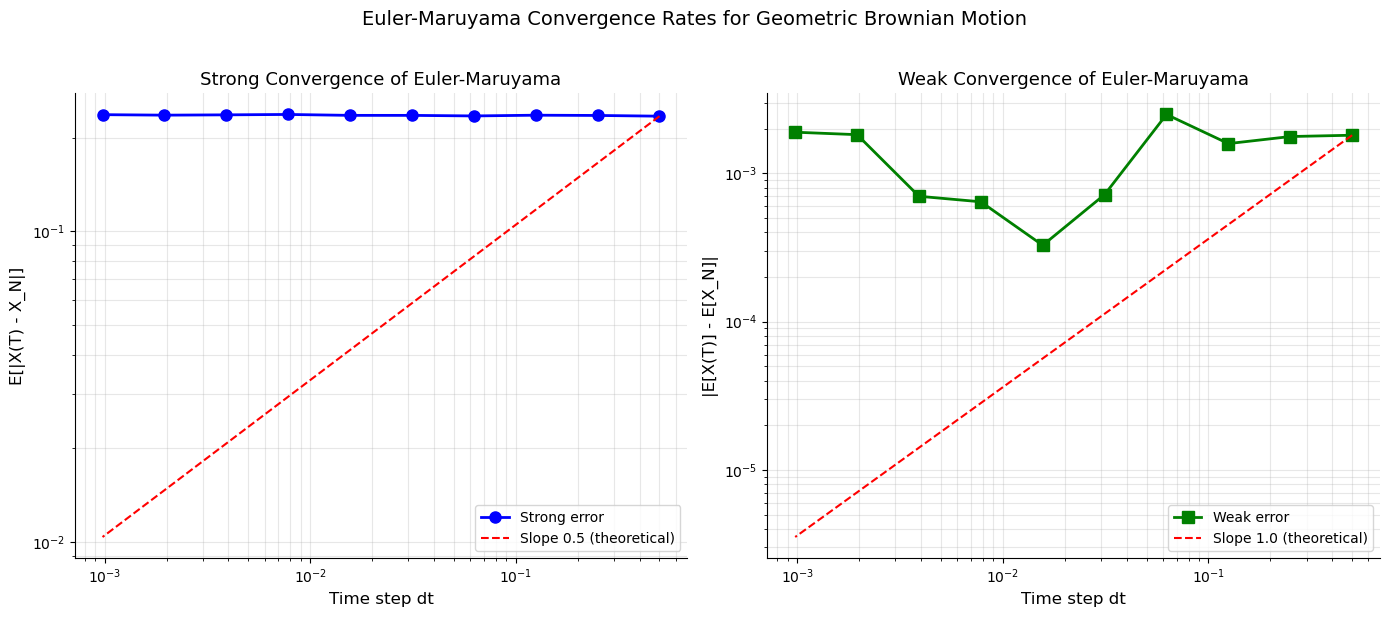

In [24]:
def gbm_exact(x0, mu, sigma, T, n_paths):
    W_T = np.random.normal(0, np.sqrt(T), n_paths)
    return x0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * W_T)

def gbm_euler(x0, mu, sigma, T, n_steps, n_paths):
    dt = T / n_steps
    X = np.full(n_paths, x0)
    for _ in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        X = X + mu * X * dt + sigma * X * dW
    return X

mu, sigma, x0, T = 0.05, 0.2, 1.0, 1.0
n_paths = 50000
n_steps_list = [2**k for k in range(1, 11)]
strong_errors, weak_errors = [], []

X_exact = gbm_exact(x0, mu, sigma, T, n_paths)

for n_steps in n_steps_list:
    X_euler = gbm_euler(x0, mu, sigma, T, n_steps, n_paths)
    strong_errors.append(np.mean(np.abs(X_exact - X_euler)))
    weak_errors.append(np.abs(np.mean(X_exact) - np.mean(X_euler)))

dt_list = [T / n for n in n_steps_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.loglog(dt_list, strong_errors, 'bo-', lw=2, markersize=8, label='Strong error')
ref_dt = np.array(dt_list)
ax.loglog(ref_dt, strong_errors[0] * (ref_dt / ref_dt[0])**0.5, 'r--', lw=1.5, 
          label='Slope 0.5 (theoretical)')
ax.set_xlabel('Time step dt', fontsize=12)
ax.set_ylabel('E[|X(T) - X_N|]', fontsize=12)
ax.set_title('Strong Convergence of Euler-Maruyama', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, which='both')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.loglog(dt_list, weak_errors, 'gs-', lw=2, markersize=8, label='Weak error')
ax.loglog(ref_dt, weak_errors[0] * (ref_dt / ref_dt[0])**1.0, 'r--', lw=1.5, 
          label='Slope 1.0 (theoretical)')
ax.set_xlabel('Time step dt', fontsize=12)
ax.set_ylabel('|E[X(T)] - E[X_N]|', fontsize=12)
ax.set_title('Weak Convergence of Euler-Maruyama', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, which='both')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Euler-Maruyama Convergence Rates for Geometric Brownian Motion', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 6: Linear Growth & Explosion

Without linear growth, solutions can **explode in finite time**. Consider $dx = x^2\,dt + 0.5\,dW$. The drift $x^2$ grows superlinearly, pushing solutions to infinity. In the deterministic case $\dot{x} = x^2$, the solution blows up at $t = 1/x(0)$. With noise, the explosion time becomes random but still finite.

Conversely, the restoring drift $b(x) = -x^3$ has superlinear growth in the negative direction, pulling trajectories back toward origin so strongly that global existence is guaranteed despite large noise. This illustrates that linear growth is **sufficient** but not **necessary** for global existence.


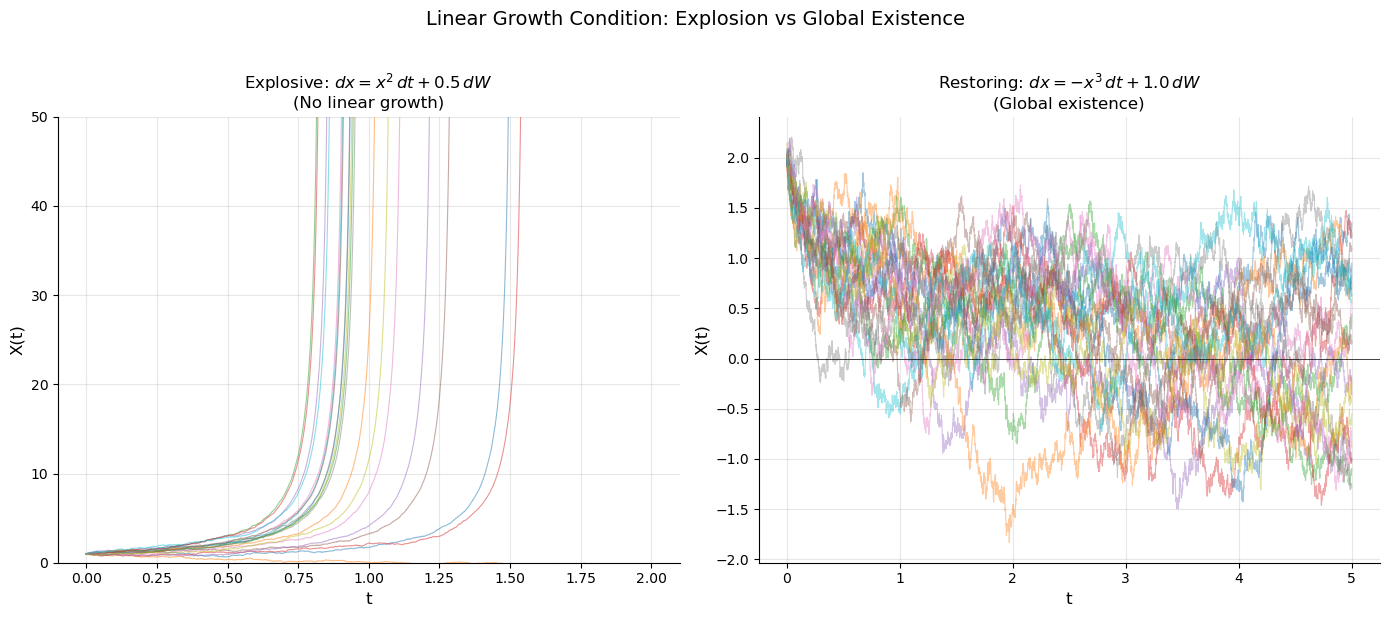

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Explosive drift
ax = axes[0]
f_exp = lambda x: x**2
g_exp = lambda x: 0.5 * np.ones_like(x)
t, X_exp = simulate_euler(f_exp, g_exp, x0=1.0, T=2.0, n_steps=2000, n_paths=20)

for k in range(20):
    path = X_exp[k]
    valid = path[np.isfinite(path)]
    t_valid = t[:len(valid)]
    ax.plot(t_valid, valid, alpha=0.5, lw=0.8)
    if len(valid) < len(t):
        ax.scatter([t_valid[-1]], [valid[-1]], color='red', s=20, zorder=5)

ax.set_title(r'Explosive: $dx = x^2 \, dt + 0.5 \, dW$' + '\n(No linear growth)', fontsize=12)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.set_ylim(0, 50)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Restoring drift
ax = axes[1]
f_rest = lambda x: -x**3
g_rest = lambda x: 1.0 * np.ones_like(x)
t, X_rest = simulate_euler(f_rest, g_rest, x0=2.0, T=5.0, n_steps=5000, n_paths=20)
for k in range(20):
    ax.plot(t, X_rest[k], alpha=0.4, lw=0.8)
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_title(r'Restoring: $dx = -x^3 \, dt + 1.0 \, dW$' + '\n(Global existence)', fontsize=12)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Linear Growth Condition: Explosion vs Global Existence', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 7: Strong vs Weak Solutions

| Concept | Definition |
|---------|-----------|
| **Strong solution** | $X(t)$ is adapted to the filtration of $W$; $X$ and $W$ live on the same probability space |
| **Weak solution** | There exists some probability space with a pair $(X, W)$ such that $W$ is a BM for $X$ |
| **Pathwise uniqueness** | If $X$ and $Y$ are two solutions on the same space with the same $W$, then $X(t) = Y(t)$ a.s. |
| **Uniqueness in law** | Any two solutions have the same finite-dimensional distributions |

### Yamada-Watanabe Principle

$$\text{Pathwise uniqueness} + \text{Weak existence} \;\Longrightarrow\; \text{Strong existence} + \text{Uniqueness in law}$$

This is a powerful result: if you can show that any two solutions driven by the same Brownian motion must coincide (pathwise uniqueness), and that at least one solution exists somewhere (weak existence), then you automatically get strong existence and uniqueness in law.

The left panel demonstrates pathwise uniqueness for the OU process: all paths driven by the same $W(t)$ but different $X(0)$ never cross. The right panel demonstrates weak uniqueness: different Brownian motions produce different paths, but all converge to the same stationary distribution $\mathcal{N}(0, \sigma^2/2\theta)$.


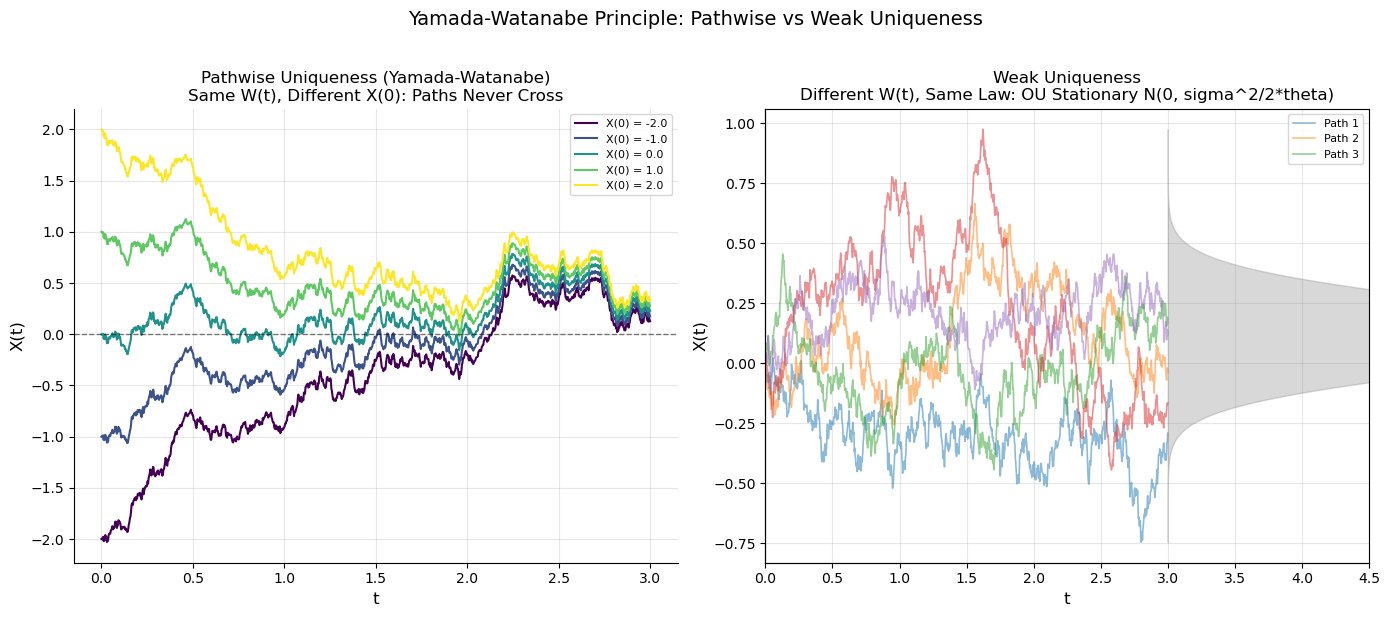

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Strong uniqueness
ax = axes[0]
T, n_steps = 3.0, 1000
dt = T / n_steps
t = np.linspace(0, T, n_steps + 1)
dW = np.random.normal(0, np.sqrt(dt), n_steps)

theta, mu, sigma = 1.0, 0.0, 0.5
x0_values = [-2.0, -1.0, 0.0, 1.0, 2.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(x0_values)))

for x0, color in zip(x0_values, colors):
    X = np.zeros(n_steps + 1)
    X[0] = x0
    for i in range(n_steps):
        X[i+1] = X[i] + theta * (mu - X[i]) * dt + sigma * dW[i]
    ax.plot(t, X, lw=1.5, color=color, label='X(0) = %.1f' % x0)

ax.axhline(y=mu, color='black', linestyle='--', lw=1, alpha=0.5)
ax.set_title('Pathwise Uniqueness (Yamada-Watanabe)\nSame W(t), Different X(0): Paths Never Cross', fontsize=12)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Weak uniqueness
ax = axes[1]
n_paths = 5
def simulate_ou(theta, mu, sigma, x0, T, n_steps, n_paths):
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    X = np.zeros((n_paths, n_steps + 1))
    X[:, 0] = x0
    for i in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        X[:, i+1] = X[:, i] + theta * (mu - X[:, i]) * dt + sigma * dW
    return t, X

t, X_all = simulate_ou(theta, mu, sigma, x0=0.0, T=T, n_steps=n_steps, n_paths=n_paths)
for k in range(n_paths):
    ax.plot(t, X_all[k], alpha=0.5, lw=1.2, label='Path %d' % (k+1) if k < 3 else '')

x_range = np.linspace(-2, 2, 200)
stat_std = sigma / np.sqrt(2 * theta)
stat_pdf = stats.norm.pdf(x_range, mu, stat_std)
ax2 = ax.twinx()
ax2.fill_betweenx(x_range, T, T + 3*stat_pdf, alpha=0.3, color='gray')
ax2.set_xlim(0, T + 1.5)
ax2.set_yticks([])

ax.set_title('Weak Uniqueness\nDifferent W(t), Same Law: OU Stationary N(0, sigma^2/2*theta)', fontsize=12)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Yamada-Watanabe Principle: Pathwise vs Weak Uniqueness', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 8: Gronwall's Lemma

**Gronwall's Lemma** is the key analytical tool for SDE proofs:

If $u(t) \leq C + K\int_0^t u(s)\,ds$, then $u(t) \leq C \cdot e^{Kt}$.

This exponential bound prevents solutions from growing too fast and is essential for proving moment estimates. In SDE theory, one typically bounds $\mathbb{E}[|X(t)|^2]$ by an integral inequality, then applies Gronwall to obtain an exponential moment bound that guarantees no finite-time explosion.

The left panel shows the second moment of a linear SDE growing exponentially, with the exact theoretical curve and the looser Gronwall bound. The right panel illustrates how different values of $C$ and $K$ affect the exponential envelope.


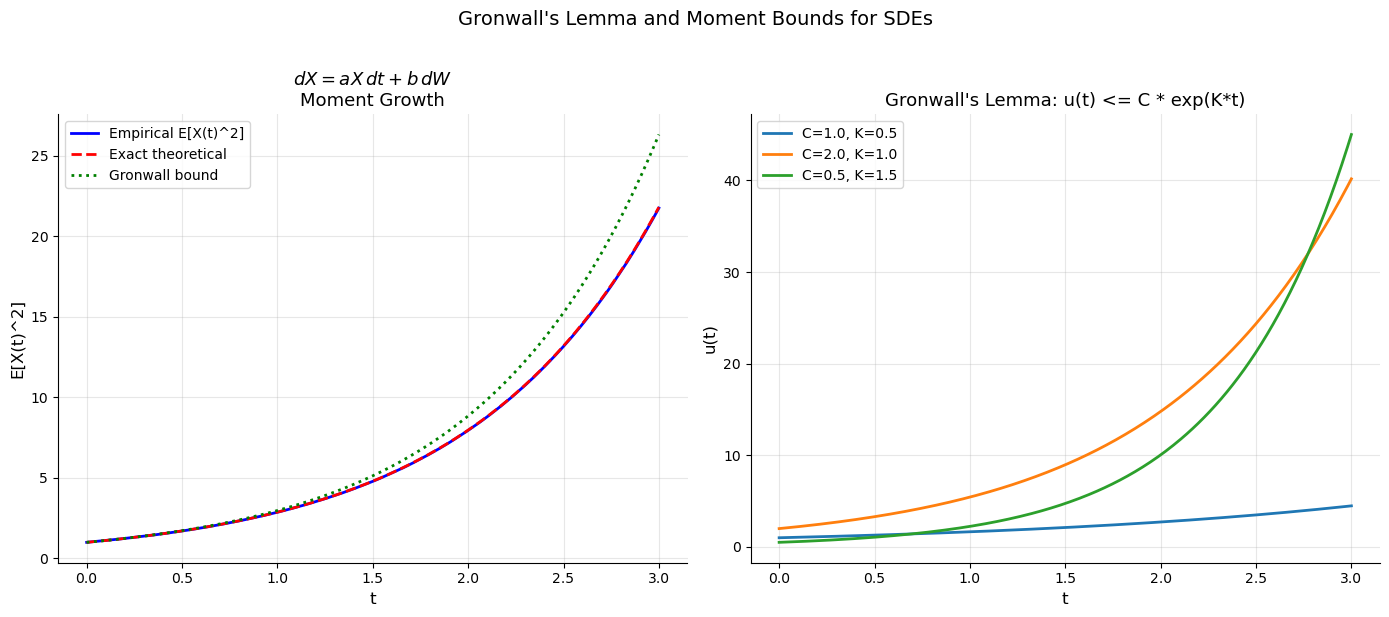

In [27]:
def simulate_moment_growth(a, b, x0, T, n_steps, n_paths):
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    X = np.zeros((n_paths, n_steps + 1))
    X[:, 0] = x0
    for i in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        X[:, i+1] = X[:, i] + a * X[:, i] * dt + b * dW
    second_moment = np.mean(X**2, axis=0)
    return t, second_moment

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
a, b, x0 = 0.5, 0.3, 1.0
T = 3.0
t, m2 = simulate_moment_growth(a, b, x0, T, 1000, 50000)
theo_m2 = x0**2 * np.exp(2*a*t) + (b**2 / (2*a)) * (np.exp(2*a*t) - 1)
C, K = x0**2, 2 * a + b**2
gronwall_bound = C * np.exp(K * t)

ax.plot(t, m2, 'b-', lw=2, label='Empirical E[X(t)^2]')
ax.plot(t, theo_m2, 'r--', lw=2, label='Exact theoretical')
ax.plot(t, gronwall_bound, 'g:', lw=2, label='Gronwall bound')
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('E[X(t)^2]', fontsize=12)
ax.set_title(r'$dX = aX \, dt + b \, dW$' + '\nMoment Growth', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
t_gr = np.linspace(0, 3, 300)
C_vals, K_vals = [1, 2, 0.5], [0.5, 1.0, 1.5]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for C, K, color in zip(C_vals, K_vals, colors):
    ax.plot(t_gr, C * np.exp(K * t_gr), lw=2, color=color,
            label='C=%.1f, K=%.1f' % (C, K))
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('u(t)', fontsize=12)
ax.set_title("Gronwall's Lemma: u(t) <= C * exp(K*t)", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle("Gronwall's Lemma and Moment Bounds for SDEs", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 9: Tanaka Equation — A Counterexample

The **Tanaka equation** is the canonical example where weak existence holds but **strong uniqueness fails**:

$$dX(t) = \text{sign}(X(t))\,dW(t), \quad X(0) = 0$$

The coefficient $\text{sign}(x)$ is **not Lipschitz** at $x=0$ (it jumps from $-1$ to $+1$).

**Result**: Both $X(t) = W(t)$ and $X(t) = -W(t)$ are valid weak solutions. Since you cannot determine the sign from the driving noise alone, no strong solution exists.

This shows that the Lipschitz condition in the existence/uniqueness theorem cannot simply be dropped. Discontinuous coefficients can lead to genuinely ambiguous dynamics where the filtration generated by the driving Brownian motion is insufficient to pin down a unique adapted solution.


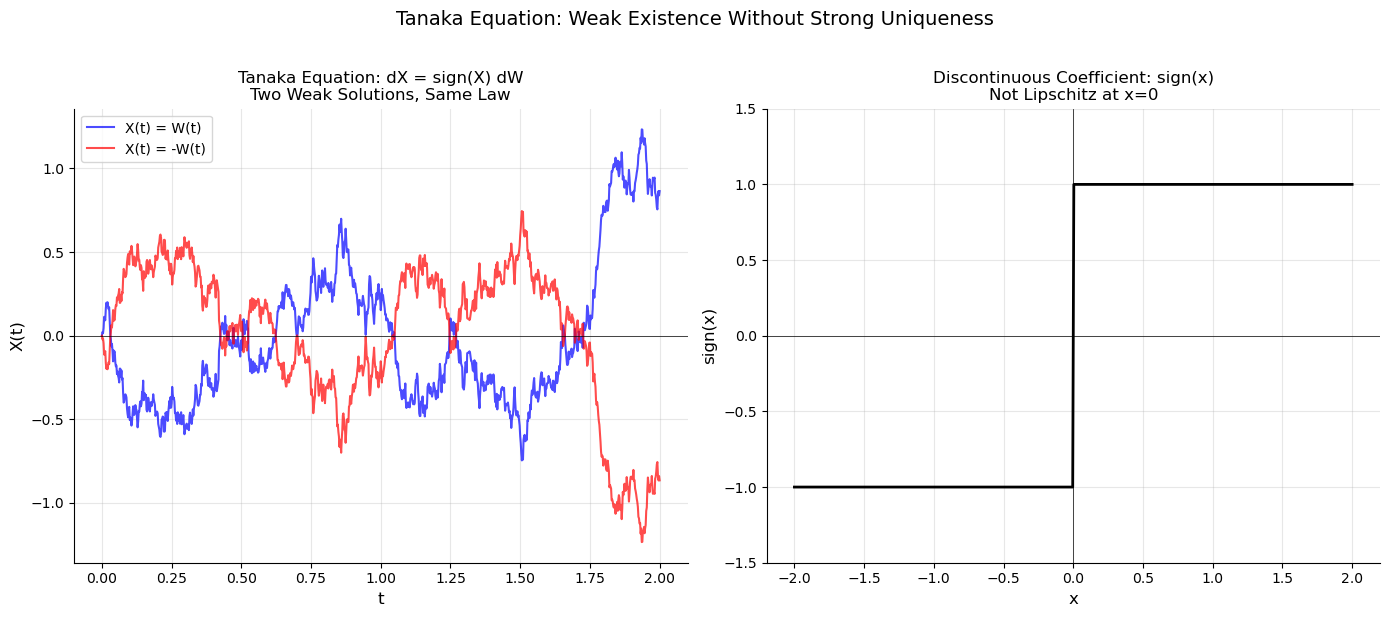

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
T, n_steps = 2.0, 1000
dt = T / n_steps
t = np.linspace(0, T, n_steps + 1)
np.random.seed(42)
dW = np.random.normal(0, np.sqrt(dt), n_steps)
W = np.concatenate([[0], np.cumsum(dW)])

ax.plot(t, W, 'b-', lw=1.5, alpha=0.7, label='X(t) = W(t)')
ax.plot(t, -W, 'r-', lw=1.5, alpha=0.7, label='X(t) = -W(t)')
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_title('Tanaka Equation: dX = sign(X) dW\nTwo Weak Solutions, Same Law', fontsize=12)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
x = np.linspace(-2, 2, 500)
ax.plot(x, np.sign(x), 'k-', lw=2)
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.axvline(x=0, color='black', linestyle='-', lw=0.5)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('sign(x)', fontsize=12)
ax.set_title('Discontinuous Coefficient: sign(x)\nNot Lipschitz at x=0', fontsize=12)
ax.set_ylim(-1.5, 1.5)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Tanaka Equation: Weak Existence Without Strong Uniqueness', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 10: Itô vs Stratonovich

| Feature | Itô | Stratonovich |
|---------|-----|--------------|
| **Definition** | Integrand at left endpoint | Integrand at midpoint |
| **Martingale** | Yes | No |
| **Chain rule** | Requires Itô's lemma (extra term) | Classical chain rule applies |
| **Drift correction** | None | Add $\frac{1}{2}\sigma\sigma'$ |
| **Use in physics** | Finance, filtering | Physical systems with white noise |

**Conversion formula**:
$$\sigma(X) \circ dW = \sigma(X)\,dW + \frac{1}{2}\sigma(X)\sigma'(X)\,dt$$

The Itô interpretation is the standard in mathematical finance because it preserves the martingale property. The Stratonovich interpretation is preferred in physics because it commutes with the classical chain rule. For the same SDE, the Itô and Stratonovich means can diverge significantly over time, especially for nonlinear noise coefficients.


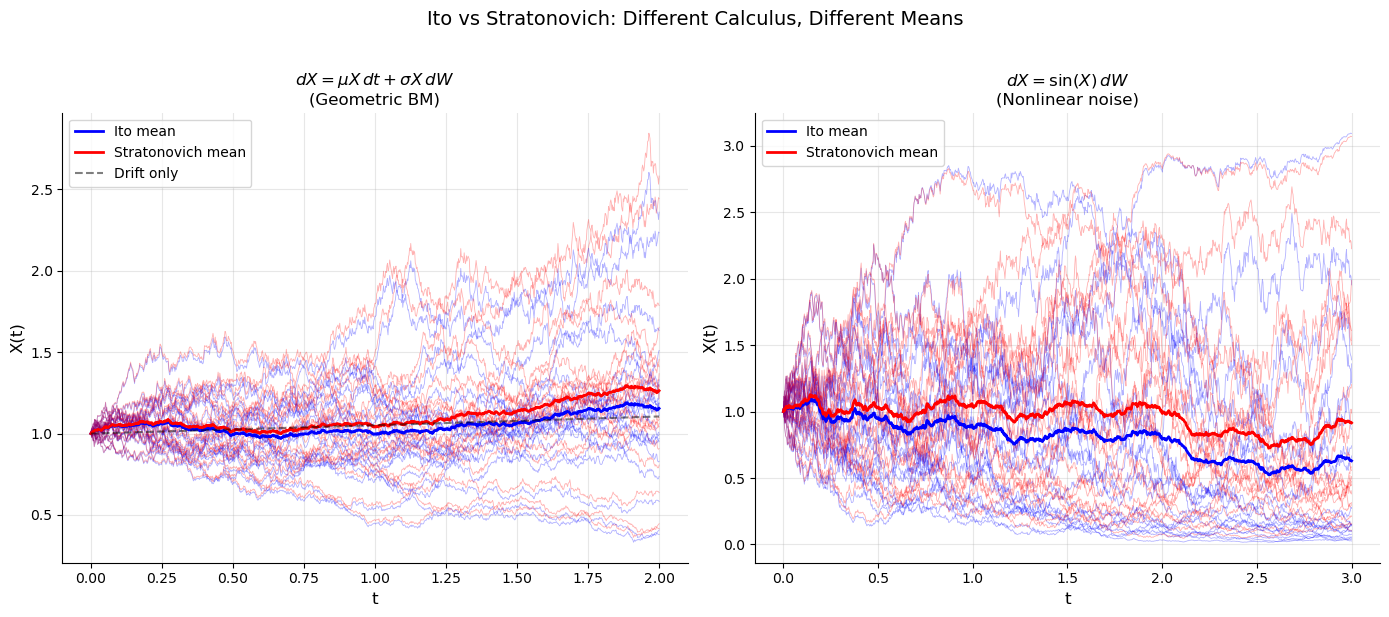

In [29]:
def simulate_ito_stratonovich(mu, sigma, dsigma, x0, T, n_steps, n_paths):
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    X_ito = np.zeros((n_paths, n_steps + 1))
    X_strat = np.zeros((n_paths, n_steps + 1))
    X_ito[:, 0] = x0
    X_strat[:, 0] = x0
    
    for i in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        X_ito[:, i+1] = X_ito[:, i] + mu * X_ito[:, i] * dt + sigma(X_ito[:, i]) * dW
        corr = 0.5 * sigma(X_strat[:, i]) * dsigma(X_strat[:, i]) * dt
        X_strat[:, i+1] = X_strat[:, i] + mu * X_strat[:, i] * dt + corr + sigma(X_strat[:, i]) * dW
    
    return t, X_ito, X_strat

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
mu = 0.05
sigma = lambda x: 0.3 * x
dsigma = lambda x: 0.3 * np.ones_like(x)
t, X_ito, X_strat = simulate_ito_stratonovich(mu, sigma, dsigma, x0=1.0, T=2.0, 
                                               n_steps=1000, n_paths=20)

for k in range(20):
    ax.plot(t, X_ito[k], alpha=0.3, lw=0.6, color='blue')
    ax.plot(t, X_strat[k], alpha=0.3, lw=0.6, color='red')

ax.plot(t, np.mean(X_ito, axis=0), 'b-', lw=2, label='Ito mean')
ax.plot(t, np.mean(X_strat, axis=0), 'r-', lw=2, label='Stratonovich mean')
ax.plot(t, 1.0 * np.exp(mu * t), 'k--', lw=1.5, alpha=0.5, label='Drift only')
ax.set_title(r'$dX = \mu X \, dt + \sigma X \, dW$' + '\n(Geometric BM)', fontsize=12)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
mu = 0.0
sigma = lambda x: np.sin(x)
dsigma = lambda x: np.cos(x)
t, X_ito2, X_strat2 = simulate_ito_stratonovich(mu, sigma, dsigma, x0=1.0, T=3.0, 
                                                 n_steps=1000, n_paths=20)

for k in range(20):
    ax.plot(t, X_ito2[k], alpha=0.3, lw=0.6, color='blue')
    ax.plot(t, X_strat2[k], alpha=0.3, lw=0.6, color='red')

ax.plot(t, np.mean(X_ito2, axis=0), 'b-', lw=2, label='Ito mean')
ax.plot(t, np.mean(X_strat2, axis=0), 'r-', lw=2, label='Stratonovich mean')
ax.set_title(r'$dX = \sin(X) \, dW$' + '\n(Nonlinear noise)', fontsize=12)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('X(t)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Ito vs Stratonovich: Different Calculus, Different Means', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Cell 11: Summary Cheat Sheet

```text
SDE EXISTENCE & UNIQUENESS

General SDE:    dX = b(X)dt + sigma(X)dW,  X(0) = x0

Ito Conditions for Strong Existence + Uniqueness:
  1. Lipschitz: |b(x)-b(y)| + |sigma(x)-sigma(y)| <= K|x-y|
  2. Linear growth: |b(x)|^2 + |sigma(x)|^2 <= C(1+|x|^2)

Then: unique strong solution exists for all t >= 0.

Picard Iteration: X_{n+1}(t) = x0 + integral b(X_n)ds + integral sigma(X_n)dW
                  Converges under Lipschitz condition

Euler-Maruyama Convergence:
  Strong: O(sqrt(dt))     [pathwise]
  Weak:   O(dt)           [distributional]

Gronwall's Lemma: u(t) <= C + K*integral_0^t u(s)ds  =>  u(t) <= C*exp(Kt)

Yamada-Watanabe:
  Pathwise uniqueness + Weak existence => Strong existence + Uniqueness in law

Tanaka Counterexample:
  dX = sign(X)dW has weak solutions but NO strong solution

Ito vs Stratonovich:
  sigma(X) circ dW = sigma(X)dW + 0.5*sigma(X)*sigma'(X)dt
